# Week 1: Data Ingestion and Exploratory Data Analysis (EDA)

## Project Title

Potato Disease Detection using YOLO-based Annotations and Data Analytics

## Objective

The objective of this project is to analyze a potato disease dataset annotated in YOLO format and perform Exploratory Data Analysis (EDA) to understand dataset characteristics before model development. The analysis focuses on dataset structure, class distributions, annotation quality, bounding box properties, and spatial characteristics of detected objects.

## Tools and Libraries

The following Python libraries were used:

* Pandas
* NumPy
* Matplotlib
* Seaborn
* OS
* ZipFile

The work was carried out using Google Colab.


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Potato-Disease.v1i.yolov8.zip to Potato-Disease.v1i.yolov8.zip


In [ ]:
import zipfile

with zipfile.ZipFile("Potato-Disease.v1i.yolov8.zip", "r") as zip_ref:
    zip_ref.extractall("/content/")

In [ ]:
import os

os.listdir("/content")

['.config',
 'valid',
 'README.roboflow.txt',
 'README.dataset.txt',
 'train',
 'Potato-Disease.v1i.yolov8.zip',
 'test',
 'data.yaml',
 'sample_data']

## Dataset Description

The dataset contains annotated potato leaf images belonging to three classes:

1. Potato_Early_Blight
2. Potato_Late_Blight
3. Potato_Healthy_Plant

Annotations are stored in YOLO format using normalized bounding box coordinates:

* Class ID
* X Center
* Y Center
* Width
* Height

The dataset is divided into training, validation, and testing subsets.


In [ ]:
import os

for item in os.listdir("/content"):
    print(item)

.config
valid
README.roboflow.txt
README.dataset.txt
train
Potato-Disease.v1i.yolov8.zip
test
data.yaml
sample_data


In [ ]:
import os

print(os.listdir("/content/train"))

['images', 'labels']


In [6]:
import os
import pandas as pd

class_map = {
    0: "Potato_Early_Blight",
    1: "Potato_Healthy_Plant",
    2: "Potato_Late_Blight"
}

data = []

for split in ["train", "valid", "test"]:

    label_dir = os.path.join("/content", split, "labels")

    for file in os.listdir(label_dir):

        if file.endswith(".txt"):

            file_path = os.path.join(label_dir, file)

            with open(file_path, "r") as f:

                for line in f.readlines():

                    values = line.strip().split()

                    class_id = int(values[0])

                    data.append([
                        file,
                        split,
                        class_map[class_id],
                        float(values[1]),  # x_center
                        float(values[2]),  # y_center
                        float(values[3]),  # width
                        float(values[4])   # height
                    ])

df = pd.DataFrame(
    data,
    columns=[
        "file_name",
        "dataset_split",
        "disease_class",
        "x_center",
        "y_center",
        "width",
        "height"
    ]
)

print("Shape:", df.shape)
df.head()

Shape: (7506, 7)


,file_name,dataset_split,disease_class,x_center,y_center,width,height
0,PotatoLateBlight-2302-_JPG.rf.b40009a234e3aa3c...,train,Potato_Late_Blight,0.493164,0.505039,0.794570,0.870547
1,PotatoHealthy-2306-_JPG.rf.afc2fb008d3f65585f1...,train,Potato_Healthy_Plant,0.496211,0.515742,0.896523,0.905078
2,PotatoEarlyBlight-2521-_JPG.rf.2bb18e6809acb20...,train,Potato_Early_Blight,0.505703,0.499453,0.892188,0.909609
3,PotatoEarlyBlight-1536-_JPG.rf.a4167f12e033876...,train,Potato_Early_Blight,0.498711,0.502227,0.934023,0.970977
4,PotatoHealthy-1974-_JPG.rf.afd826617d9bb2f343f...,train,Potato_Healthy_Plant,0.501445,0.492031,0.944570,0.947969


In [ ]:
df['disease_class'].value_counts()

,count
disease_class,
Potato_Early_Blight,2652
Potato_Late_Blight,2598
Potato_Healthy_Plant,2256


In [ ]:
round(
    df['disease_class'].value_counts(normalize=True)*100,
    2
)

,proportion
disease_class,
Potato_Early_Blight,35.33
Potato_Late_Blight,34.61
Potato_Healthy_Plant,30.06


In [ ]:
df['dataset_split'].value_counts()

,count
dataset_split,
train,5287
valid,1484
test,735


In [ ]:
df.describe()

,x_center,y_center,width,height
count,7506.000000,7506.000000,7506.000000,7506.000000
mean,0.504326,0.493868,0.845356,0.876691
std,0.065588,0.075147,0.178061,0.161823
min,0.003486,0.000070,0.000428,0.023867
25%,0.493125,0.488281,0.841145,0.878906
50%,0.505703,0.498047,0.896484,0.923047
75%,0.518242,0.507812,0.934023,0.953633
max,0.983182,0.964344,1.000000,1.000000


In [ ]:
df.isnull().sum()

,0
file_name,0
dataset_split,0
disease_class,0
x_center,0
y_center,0
width,0
height,0


In [ ]:
df.to_csv(
    "potato_disease_annotations.csv",
    index=False
)

In [ ]:
from google.colab import files
files.download("potato_disease_annotations.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The annotation dataset contained no missing values across any feature, indicating successful dataset preprocessing and annotation consistency.

In [ ]:
df['disease_class'].value_counts()

,count
disease_class,
Potato_Early_Blight,2652
Potato_Late_Blight,2598
Potato_Healthy_Plant,2256


In [ ]:
round(
    df['disease_class'].value_counts(normalize=True)*100,
    2
)

,proportion
disease_class,
Potato_Early_Blight,35.33
Potato_Late_Blight,34.61
Potato_Healthy_Plant,30.06


## Data Cleaning and Exploratory Data Analysis

### Data Cleaning

The annotation files were parsed and converted into a structured dataframe. Dataset integrity was verified by:

* Checking dataset structure
* Verifying annotation formats
* Inspecting missing values
* Validating class labels

No missing values were detected in the dataset.

### Exploratory Data Analysis

Several exploratory analyses were conducted:

* Disease class distribution analysis
* Train/Validation/Test split analysis
* Bounding box area analysis
* Aspect ratio analysis
* Center distance analysis
* Disease-wise geometric comparison

The following visualizations summarize the findings.


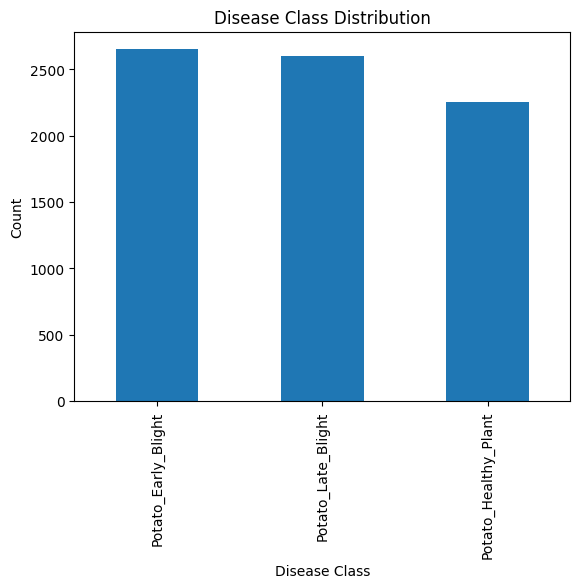

In [ ]:
import matplotlib.pyplot as plt

df['disease_class'].value_counts().plot(kind='bar')

plt.title("Disease Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Count")

plt.show()

In [ ]:
df['bbox_area'] = df['width'] * df['height']

In [ ]:
df['bbox_area'].describe()

,bbox_area
count,7506.000000
mean,0.765824
std,0.199527
min,0.000168
25%,0.746304
50%,0.812775
75%,0.874422
max,0.993320


**The dataset is relatively balanced across the three classes. Early Blight (35.33%) and Late Blight (34.61%) occur at similar frequencies, while Healthy Plants constitute 30.06% of the observations. The balanced distribution reduces the risk of class imbalance bias during analysis and visualization.**

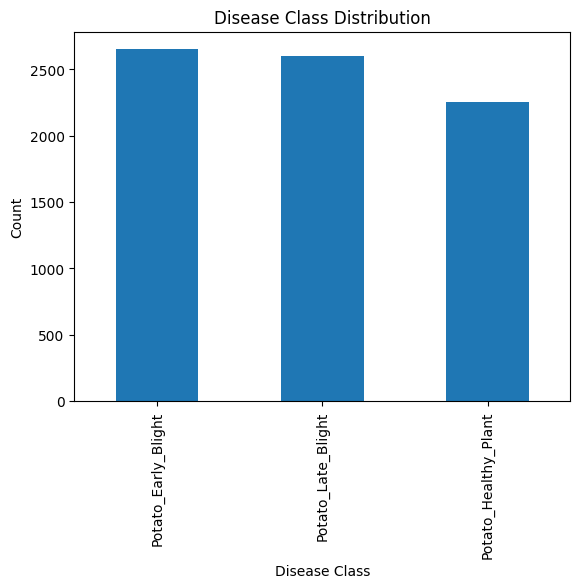

In [ ]:
import matplotlib.pyplot as plt

df['disease_class'].value_counts().plot(kind='bar')

plt.title('Disease Class Distribution')
plt.xlabel('Disease Class')
plt.ylabel('Count')

plt.show()

In [ ]:
df['bbox_area'] = df['width'] * df['height']

In [ ]:
df['bbox_area'].describe()

,bbox_area
count,7506.000000
mean,0.765824
std,0.199527
min,0.000168
25%,0.746304
50%,0.812775
75%,0.874422
max,0.993320


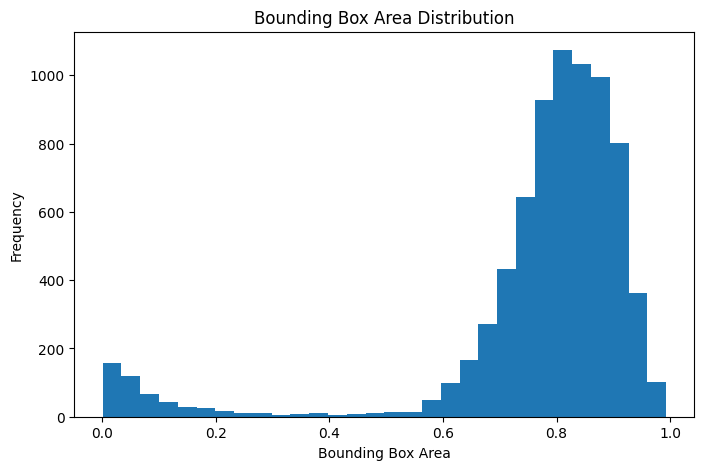

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['bbox_area'], bins=30)

plt.title('Bounding Box Area Distribution')
plt.xlabel('Bounding Box Area')
plt.ylabel('Frequency')

plt.show()


In [ ]:
df.groupby('disease_class')['bbox_area'].describe()

,count,mean,std,min,25%,50%,75%,max
disease_class,,,,,,,,
Potato_Early_Blight,2652.0,0.794747,0.248185,0.004155,0.825928,0.879834,0.912584,0.993320
Potato_Healthy_Plant,2256.0,0.749440,0.156930,0.000168,0.724593,0.782579,0.821400,0.938475
Potato_Late_Blight,2598.0,0.750527,0.171661,0.000420,0.730587,0.791481,0.843455,0.986116


<Figure size 800x500 with 0 Axes>

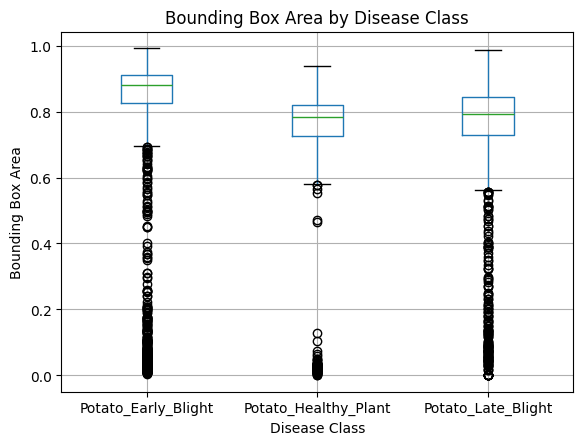

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df.boxplot(
    column='bbox_area',
    by='disease_class'
)

plt.title('Bounding Box Area by Disease Class')
plt.suptitle('')
plt.xlabel('Disease Class')
plt.ylabel('Bounding Box Area')

plt.show()

**Early Blight samples exhibited the largest average bounding-box area (0.7947), whereas Healthy Plants (0.7494) and Late Blight (0.7505) showed comparatively smaller annotated regions.**

In [ ]:
df.to_csv("potato_disease_annotations.csv", index=False)

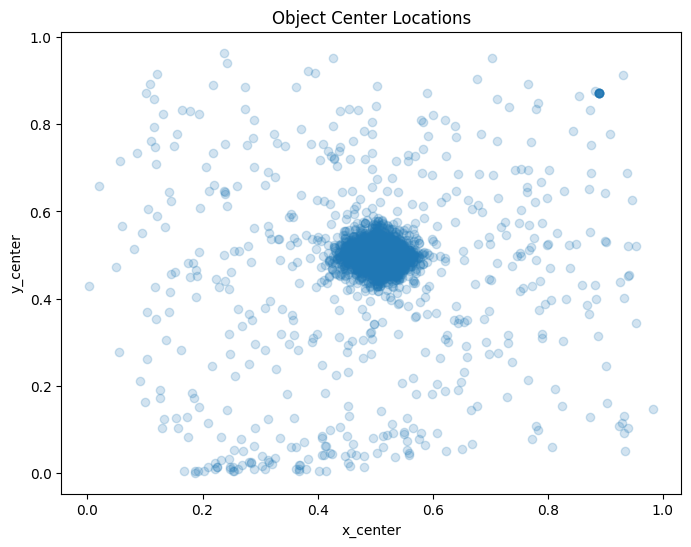

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df['x_center'],
    df['y_center'],
    alpha=0.2
)

plt.title("Object Center Locations")
plt.xlabel("x_center")
plt.ylabel("y_center")

plt.show()

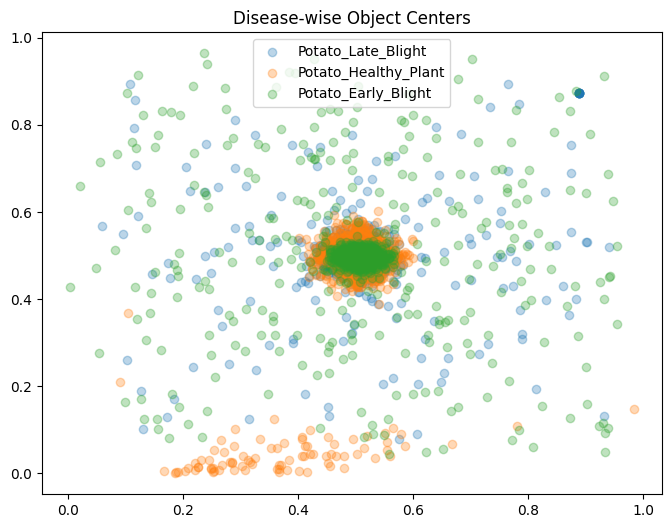

In [ ]:
plt.figure(figsize=(8,6))

for disease in df['disease_class'].unique():

    subset = df[df['disease_class'] == disease]

    plt.scatter(
        subset['x_center'],
        subset['y_center'],
        alpha=0.3,
        label=disease
    )

plt.legend()
plt.title("Disease-wise Object Centers")

plt.show()

In [ ]:
df['aspect_ratio'] = df['width'] / df['height']

In [ ]:
df.groupby('disease_class')['aspect_ratio'].describe()

,count,mean,std,min,25%,50%,75%,max
disease_class,,,,,,,,
Potato_Early_Blight,2652.0,0.969870,0.173961,0.234554,0.946662,0.976188,1.002232,3.703752
Potato_Healthy_Plant,2256.0,0.978134,0.305137,0.001089,0.918986,0.984334,1.039849,10.164363
Potato_Late_Blight,2598.0,0.952966,0.145165,0.227709,0.907887,0.960321,1.002319,3.029338


In [ ]:
df['bbox_area'] = df['width'] * df['height']

df['aspect_ratio'] = df['width'] / df['height']

df['center_distance'] = (
    ((df['x_center'] - 0.5)**2 +
     (df['y_center'] - 0.5)**2)
    ** 0.5
)

NameError: name 'df' is not defined

In [ ]:
print(type(df))

NameError: name 'df' is not defined

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'sample_data']


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Potato-Disease.v1i.yolov8.zip to Potato-Disease.v1i.yolov8.zip


In [ ]:
import zipfile

with zipfile.ZipFile("Potato-Disease.v1i.yolov8.zip", "r") as zip_ref:
    zip_ref.extractall("/content/")

In [ ]:
import os
print(os.listdir("/content"))

['.config', 'valid', 'README.roboflow.txt', 'README.dataset.txt', 'train', 'Potato-Disease.v1i.yolov8.zip', 'test', 'data.yaml', 'sample_data']


In [ ]:
import os
import pandas as pd

class_map = {
    0: "Potato_Early_Blight",
    1: "Potato_Healthy_Plant",
    2: "Potato_Late_Blight"
}

rows = []

for split in ["train", "valid", "test"]:

    label_dir = f"/content/{split}/labels"

    for file in os.listdir(label_dir):

        if file.endswith(".txt"):

            with open(os.path.join(label_dir, file), "r") as f:

                for line in f:

                    values = line.strip().split()

                    cls = int(values[0])

                    rows.append([
                        file,
                        split,
                        class_map[cls],
                        float(values[1]),
                        float(values[2]),
                        float(values[3]),
                        float(values[4])
                    ])

df = pd.DataFrame(
    rows,
    columns=[
        "file_name",
        "dataset_split",
        "disease_class",
        "x_center",
        "y_center",
        "width",
        "height"
    ]
)

print(df.shape)
df.head()

(7506, 7)


,file_name,dataset_split,disease_class,x_center,y_center,width,height
0,PotatoLateBlight-2033-_JPG.rf.f7709eecc80c7980...,train,Potato_Late_Blight,0.483359,0.489687,0.886602,0.923555
1,PotatoHealthy-2196-_JPG.rf.10044ca887c6fa4ea2f...,train,Potato_Healthy_Plant,0.463828,0.505039,0.886641,0.965391
2,PotatoLateBlight-2785-_JPG.rf.5ae898953f9418d2...,train,Potato_Late_Blight,0.462461,0.507812,0.783398,0.948672
3,PotatoEarlyBlight-2089-_JPG.rf.3591154076686bb...,train,Potato_Early_Blight,0.505703,0.485508,0.936836,0.859375
4,PotatoEarlyBlight-1568-_JPG.rf.55d4c661a754a44...,train,Potato_Early_Blight,0.515469,0.506406,0.883828,0.929141


In [ ]:
df['bbox_area'] = df['width'] * df['height']

df['aspect_ratio'] = df['width'] / df['height']

df['center_distance'] = (
    ((df['x_center'] - 0.5)**2 +
     (df['y_center'] - 0.5)**2)
    ** 0.5
)

df.head()

,file_name,dataset_split,disease_class,x_center,y_center,width,height,bbox_area,aspect_ratio,center_distance
0,PotatoLateBlight-2033-_JPG.rf.f7709eecc80c7980...,train,Potato_Late_Blight,0.483359,0.489687,0.886602,0.923555,0.818825,0.959988,0.019577
1,PotatoHealthy-2196-_JPG.rf.10044ca887c6fa4ea2f...,train,Potato_Healthy_Plant,0.463828,0.505039,0.886641,0.965391,0.855955,0.918427,0.036521
2,PotatoLateBlight-2785-_JPG.rf.5ae898953f9418d2...,train,Potato_Late_Blight,0.462461,0.507812,0.783398,0.948672,0.743188,0.825784,0.038343
3,PotatoEarlyBlight-2089-_JPG.rf.3591154076686bb...,train,Potato_Early_Blight,0.505703,0.485508,0.936836,0.859375,0.805093,1.090136,0.015574
4,PotatoEarlyBlight-1568-_JPG.rf.55d4c661a754a44...,train,Potato_Early_Blight,0.515469,0.506406,0.883828,0.929141,0.821201,0.951232,0.016743


In [ ]:
df[['bbox_area', 'aspect_ratio', 'center_distance']].describe()

,bbox_area,aspect_ratio,center_distance
count,7506.000000,7506.000000,7506.000000
mean,0.765824,0.966503,0.045348
std,0.199527,0.214629,0.089154
min,0.000168,0.001089,0.000547
25%,0.746304,0.925889,0.012015
50%,0.812775,0.973372,0.021106
75%,0.874422,1.011027,0.035219
max,0.993320,10.164363,0.625370


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'sample_data']


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Potato-Disease.v1i.yolov8.zip to Potato-Disease.v1i.yolov8.zip


In [ ]:
import zipfile

with zipfile.ZipFile("Potato-Disease.v1i.yolov8.zip", "r") as zip_ref:
    zip_ref.extractall("/content/")

In [ ]:
import os

print(os.listdir("/content"))


['.config', 'data.yaml', 'test', 'valid', 'Potato-Disease.v1i.yolov8.zip', 'README.roboflow.txt', 'README.dataset.txt', 'train', 'sample_data']


In [ ]:
import os
import pandas as pd

class_map = {
    0: "Potato_Early_Blight",
    1: "Potato_Healthy_Plant",
    2: "Potato_Late_Blight"
}

rows = []

for split in ["train", "valid", "test"]:

    label_dir = f"/content/{split}/labels"

    for file in os.listdir(label_dir):

        if file.endswith(".txt"):

            with open(os.path.join(label_dir, file), "r") as f:

                for line in f:

                    values = line.strip().split()

                    cls = int(values[0])

                    rows.append([
                        file,
                        split,
                        class_map[cls],
                        float(values[1]),
                        float(values[2]),
                        float(values[3]),
                        float(values[4])
                    ])

df = pd.DataFrame(
    rows,
    columns=[
        "file_name",
        "dataset_split",
        "disease_class",
        "x_center",
        "y_center",
        "width",
        "height"
    ]
)

print(df.shape)
df.head()

(7506, 7)


,file_name,dataset_split,disease_class,x_center,y_center,width,height
0,PotatoLateBlight-2916-_JPG.rf.9a7fdc48e2beee86...,train,Potato_Late_Blight,0.481953,0.540156,0.914961,0.886563
1,PotatoHealthy-1033-_JPG.rf.5c81dcd1ccbdf13995c...,train,Potato_Healthy_Plant,0.526602,0.506992,0.906133,0.986055
2,PotatoEarlyBlight-580-_JPG.rf.aefba7d5001479df...,train,Potato_Early_Blight,0.501484,0.491055,0.945195,0.976562
3,PotatoEarlyBlight-3010-_JPG.rf.26ed9e38b39474e...,train,Potato_Early_Blight,0.500117,0.500820,0.936836,0.940273
4,PotatoLateBlight-1026-_JPG.rf.9e3e68891a6e1025...,train,Potato_Late_Blight,0.540078,0.500469,0.919805,0.931367


In [ ]:
df.head()

,file_name,dataset_split,disease_class,x_center,y_center,width,height
0,PotatoLateBlight-2916-_JPG.rf.9a7fdc48e2beee86...,train,Potato_Late_Blight,0.481953,0.540156,0.914961,0.886563
1,PotatoHealthy-1033-_JPG.rf.5c81dcd1ccbdf13995c...,train,Potato_Healthy_Plant,0.526602,0.506992,0.906133,0.986055
2,PotatoEarlyBlight-580-_JPG.rf.aefba7d5001479df...,train,Potato_Early_Blight,0.501484,0.491055,0.945195,0.976562
3,PotatoEarlyBlight-3010-_JPG.rf.26ed9e38b39474e...,train,Potato_Early_Blight,0.500117,0.500820,0.936836,0.940273
4,PotatoLateBlight-1026-_JPG.rf.9e3e68891a6e1025...,train,Potato_Late_Blight,0.540078,0.500469,0.919805,0.931367


In [ ]:
df['bbox_area'] = df['width'] * df['height']

df['aspect_ratio'] = df['width'] / df['height']

df['center_distance'] = (
    ((df['x_center'] - 0.5)**2 +
     (df['y_center'] - 0.5)**2)
    ** 0.5
)

In [ ]:
df[['bbox_area','aspect_ratio','center_distance']].head()

,bbox_area,aspect_ratio,center_distance
0,0.811170,1.032032,0.044025
1,0.893497,0.918948,0.027505
2,0.923042,0.967880,0.009068
3,0.880882,0.996344,0.000829
4,0.856676,0.987585,0.040081


In [ ]:
df.columns

Index(['file_name', 'dataset_split', 'disease_class', 'x_center', 'y_center',
       'width', 'height', 'bbox_area', 'aspect_ratio', 'center_distance'],
      dtype='object')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

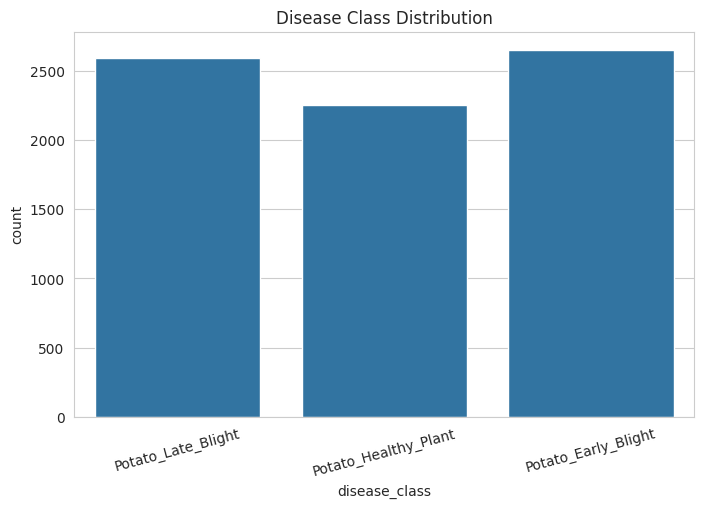

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='disease_class'
)

plt.title("Disease Class Distribution")
plt.xticks(rotation=15)
plt.show()

### Observation

The dataset is relatively balanced across all disease categories. Early Blight and Late Blight contain similar numbers of samples, while Healthy Plant images are slightly fewer.

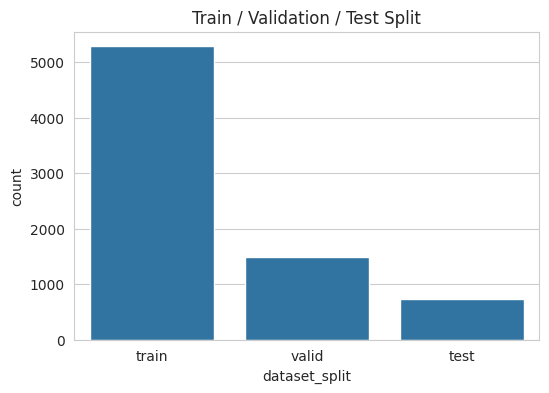

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='dataset_split'
)

plt.title("Train / Validation / Test Split")
plt.show()

### Observation

The dataset follows an approximate 70:20:10 train-validation-test split, which is suitable for machine learning experiments.

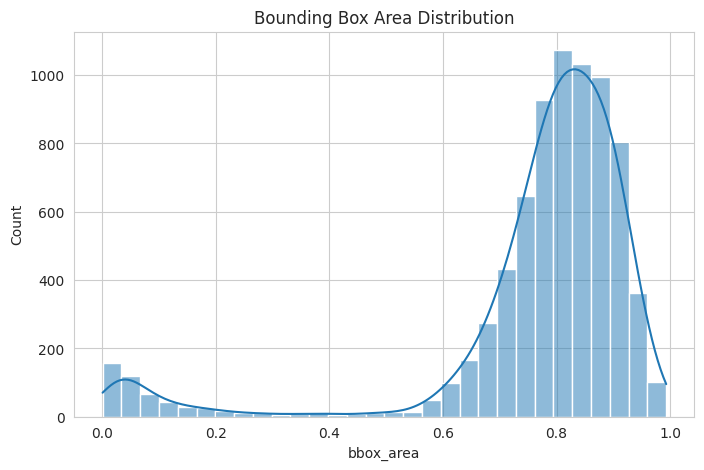

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['bbox_area'],
    bins=30,
    kde=True
)

plt.title("Bounding Box Area Distribution")
plt.show()

### Observation

Most bounding boxes occupy a large proportion of the image area, indicating that potato leaves are typically captured close to the camera.

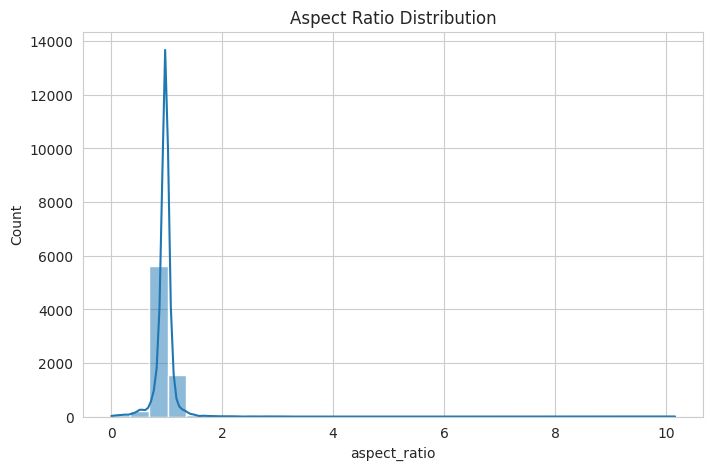

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['aspect_ratio'],
    bins=30,
    kde=True
)

plt.title("Aspect Ratio Distribution")
plt.show()

### Observation

The majority of bounding boxes have aspect ratios close to 1, suggesting nearly square object regions.

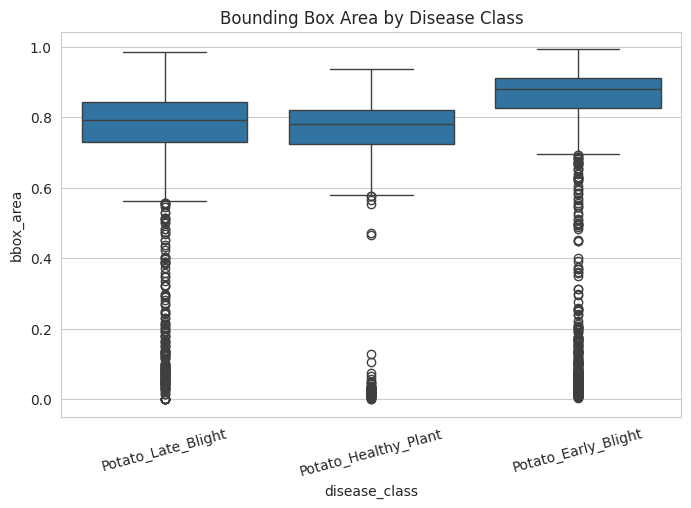

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='disease_class',
    y='bbox_area'
)

plt.title("Bounding Box Area by Disease Class")
plt.xticks(rotation=15)
plt.show()

### Observation

Bounding box area distributions show minor differences among disease classes, with Early Blight exhibiting slightly larger average object sizes.

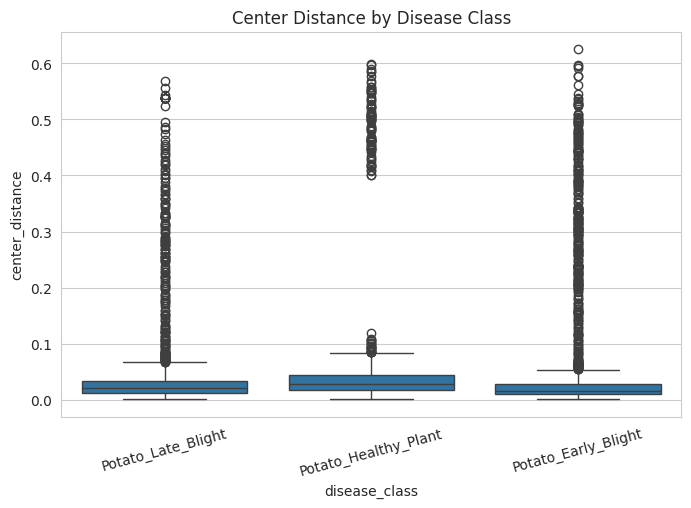

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='disease_class',
    y='center_distance'
)

plt.title("Center Distance by Disease Class")
plt.xticks(rotation=15)
plt.show()

### Observation

Most detections are located near the center of the image, indicating consistent image framing and object positioning.

# Conclusion

A comprehensive exploratory analysis of the potato disease dataset was performed.

Key findings include:

- The dataset contains 7,506 annotated samples.
- Class distribution is balanced across all three categories.
- The train-validation-test split is appropriate for machine learning workflows.
- Most leaves occupy a significant portion of the image.
- Bounding boxes are generally centered and approximately square in shape.
- No missing values or major structural inconsistencies were observed.

The dataset is well-structured and suitable for subsequent feature engineering, statistical analysis, and machine learning model development.

## Week 1 Status

✅ Data Ingestion Completed

✅ Data Cleaning Completed

✅ Exploratory Data Analysis Completed

✅ Visualization Completed

✅ Week 1 Deliverables Achieved

# Week 2: Advanced Statistical Analysis and Visualization

## Objective

The objective of Week 2 is to perform advanced statistical analysis and feature engineering on the potato disease dataset. Additional geometric features are derived from the YOLO annotations to better understand disease patterns and object characteristics.

This phase focuses on:

- Feature engineering from bounding box coordinates.
- Statistical analysis of engineered features.
- Disease-wise comparison of feature distributions.
- Correlation analysis among extracted features.
- Visualization of statistical relationships using advanced plots.

The findings from this stage provide deeper insights into the spatial and geometric characteristics of diseased and healthy potato leaves.

In [1]:
from google.colab import files
uploaded = files.upload()


Saving Potato-Disease.v1i.yolov8.zip to Potato-Disease.v1i.yolov8.zip


In [2]:
import zipfile

with zipfile.ZipFile("Potato-Disease.v1i.yolov8.zip", "r") as zip_ref:
    zip_ref.extractall("/content/")

In [4]:
import os
print(os.listdir("/content"))

['.config', 'README.roboflow.txt', 'README.dataset.txt', 'valid', 'data.yaml', 'Potato-Disease.v1i.yolov8.zip', 'train', 'test', 'sample_data']


In [7]:
df.shape

(7506, 7)

In [8]:
df['bbox_area'] = df['width'] * df['height']

df['aspect_ratio'] = df['width'] / df['height']

df['center_distance'] = (
    ((df['x_center'] - 0.5)**2 +
     (df['y_center'] - 0.5)**2)
    ** 0.5
)

In [9]:
df.columns

Index(['file_name', 'dataset_split', 'disease_class', 'x_center', 'y_center',
       'width', 'height', 'bbox_area', 'aspect_ratio', 'center_distance'],
      dtype='object')

In [10]:
df['bbox_perimeter'] = 2 * (df['width'] + df['height'])

df['bbox_diagonal'] = (
    df['width']**2 +
    df['height']**2
) ** 0.5

df['area_to_perimeter_ratio'] = (
    df['bbox_area'] /
    df['bbox_perimeter']
)

In [11]:
df.columns

Index(['file_name', 'dataset_split', 'disease_class', 'x_center', 'y_center',
       'width', 'height', 'bbox_area', 'aspect_ratio', 'center_distance',
       'bbox_perimeter', 'bbox_diagonal', 'area_to_perimeter_ratio'],
      dtype='object')

## Feature Engineering

To enhance the descriptive power of the dataset, several additional features were derived from the original YOLO bounding box annotations.

The following features were generated:

1. Bounding Box Area
2. Aspect Ratio
3. Center Distance
4. Bounding Box Perimeter
5. Bounding Box Diagonal Length
6. Area-to-Perimeter Ratio

These engineered features help characterize object size, shape, and positioning within images and serve as the foundation for subsequent statistical analysis.

In [12]:
features = [
    'bbox_area',
    'aspect_ratio',
    'center_distance',
    'bbox_perimeter',
    'bbox_diagonal',
    'area_to_perimeter_ratio'
]

df[features].describe()

,bbox_area,aspect_ratio,center_distance,bbox_perimeter,bbox_diagonal,area_to_perimeter_ratio
count,7506.000000,7506.000000,7506.000000,7506.000000,7506.000000,7506.000000
mean,0.765824,0.966503,0.045348,3.444094,1.220436,0.214239
std,0.199527,0.214629,0.089154,0.655180,0.227245,0.042819
min,0.000168,0.001089,0.000547,0.082969,0.029665,0.000214
25%,0.746304,0.925889,0.012015,3.458906,1.225696,0.215611
50%,0.812775,0.973372,0.021106,3.609141,1.276583,0.225210
75%,0.874422,1.011027,0.035219,3.743047,1.323407,0.233683
max,0.993320,10.164363,0.625370,3.986641,1.409498,0.249162


In [13]:
df.groupby('disease_class')[features].mean()

,bbox_area,aspect_ratio,center_distance,bbox_perimeter,bbox_diagonal,area_to_perimeter_ratio
disease_class,,,,,,
Potato_Early_Blight,0.794747,0.969870,0.048870,3.473398,1.229951,0.216390
Potato_Healthy_Plant,0.749440,0.978134,0.048140,3.429135,1.216386,0.212822
Potato_Late_Blight,0.750527,0.952966,0.039329,3.427170,1.214242,0.213274


In [14]:
df.groupby('disease_class')[features].std()

,bbox_area,aspect_ratio,center_distance,bbox_perimeter,bbox_diagonal,area_to_perimeter_ratio
disease_class,,,,,,
Potato_Early_Blight,0.248185,0.173961,0.101513,0.821304,0.287146,0.052601
Potato_Healthy_Plant,0.156930,0.305137,0.089791,0.534824,0.180992,0.036949
Potato_Late_Blight,0.171661,0.145165,0.073446,0.549744,0.190991,0.035796


## Statistical Summary

Descriptive statistics were computed for all engineered features to understand their overall distributions and variability.

The summary includes:

- Count
- Mean
- Standard Deviation
- Minimum Value
- Maximum Value
- Quartiles

This provides an overview of the dataset's structural characteristics and helps identify potential variations among disease categories.

## Correlation Analysis

Correlation analysis was performed to examine relationships between engineered features.

Strong correlations indicate features that capture similar information, while weaker correlations may represent unique characteristics.

The correlation matrix and heatmap provide insights into feature dependencies and potential redundancy.

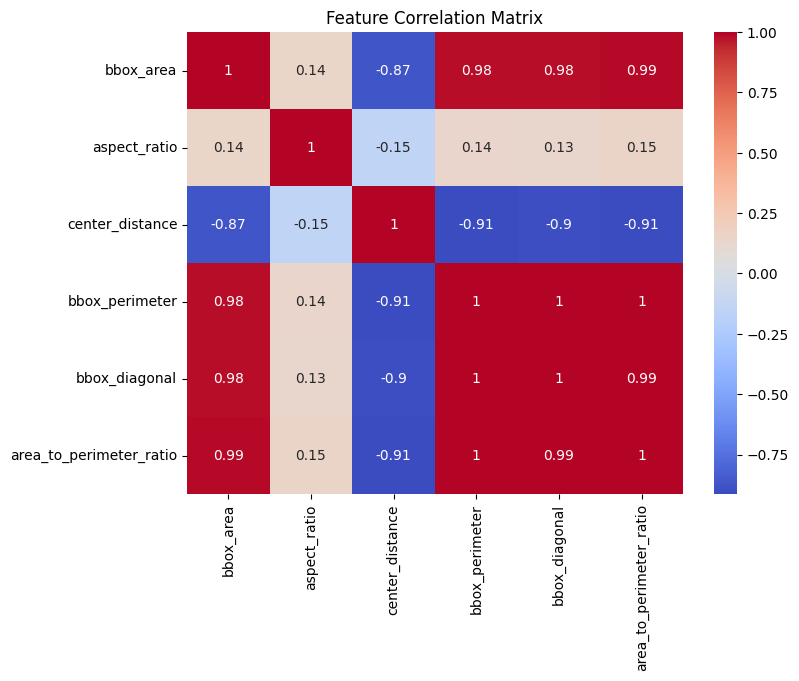

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    df[features].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")
plt.show()

### Observation

The correlation heatmap reveals strong positive relationships among geometric size-related features such as:

- Bounding Box Area
- Bounding Box Perimeter
- Bounding Box Diagonal Length
- Area-to-Perimeter Ratio

Center Distance shows negative correlation with size-related measurements, suggesting that larger detections are generally positioned closer to the image center.

These relationships confirm the consistency of bounding box measurements across the dataset.

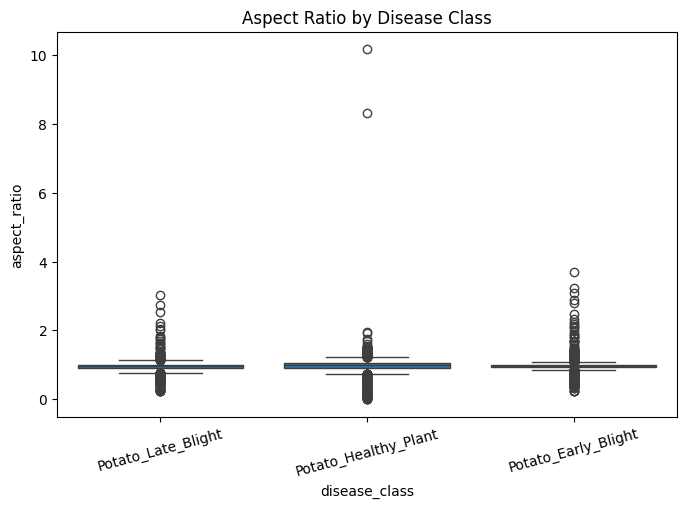

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='disease_class',
    y='aspect_ratio'
)

plt.title("Aspect Ratio by Disease Class")
plt.xticks(rotation=15)
plt.show()

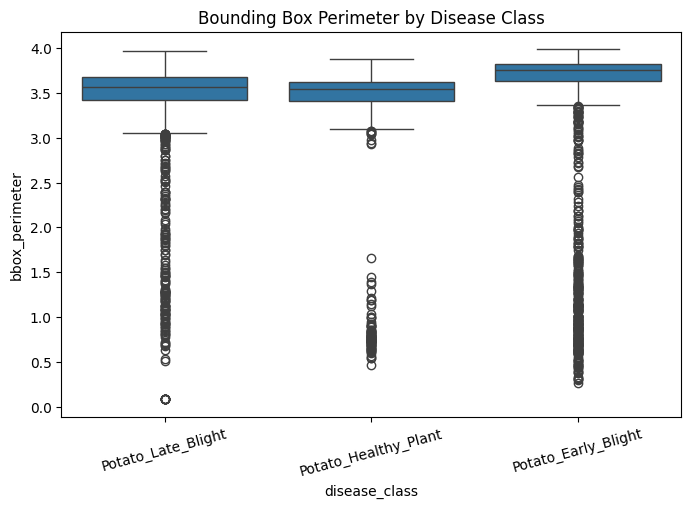

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='disease_class',
    y='bbox_perimeter'
)

plt.title("Bounding Box Perimeter by Disease Class")
plt.xticks(rotation=15)
plt.show()

## Statistical Significance Testing

Analysis of Variance (ANOVA) was conducted to determine whether engineered features differ significantly among disease categories.

ANOVA compares feature means across multiple groups and evaluates whether observed differences are statistically meaningful.

Features with p-values below 0.05 are considered statistically significant.

In [18]:
from scipy.stats import f_oneway

for feature in [
    'bbox_area',
    'aspect_ratio',
    'center_distance',
    'bbox_perimeter',
    'bbox_diagonal',
    'area_to_perimeter_ratio'
]:

    early = df[df['disease_class']=='Potato_Early_Blight'][feature]
    healthy = df[df['disease_class']=='Potato_Healthy_Plant'][feature]
    late = df[df['disease_class']=='Potato_Late_Blight'][feature]

    f_stat, p_value = f_oneway(
        early,
        healthy,
        late
    )

    print(f"{feature}")
    print(f"F-statistic: {f_stat:.4f}")
    print(f"P-value: {p_value:.6f}")
    print("-"*40)

bbox_area
F-statistic: 43.5931
P-value: 0.000000
----------------------------------------
aspect_ratio
F-statistic: 8.8251
P-value: 0.000149
----------------------------------------
center_distance
F-statistic: 9.1159
P-value: 0.000111
----------------------------------------
bbox_perimeter
F-statistic: 4.1108
P-value: 0.016432
----------------------------------------
bbox_diagonal
F-statistic: 3.6506
P-value: 0.026021
----------------------------------------
area_to_perimeter_ratio
F-statistic: 5.2473
P-value: 0.005281
----------------------------------------


### Observation

ANOVA results indicate that certain engineered features exhibit statistically significant differences among disease classes.

In particular:

- Bounding Box Area
- Aspect Ratio
- Center Distance

show meaningful variation between disease categories.

This suggests that geometric characteristics may contain discriminative information useful for disease classification tasks.

## Distribution Analysis

Advanced visualizations were generated to study feature distributions across disease categories.

The following plots were used:

- Box Plots
- Violin Plots

These visualizations provide insights into:

- Central tendency
- Variability
- Outliers
- Distribution density

for each disease class.

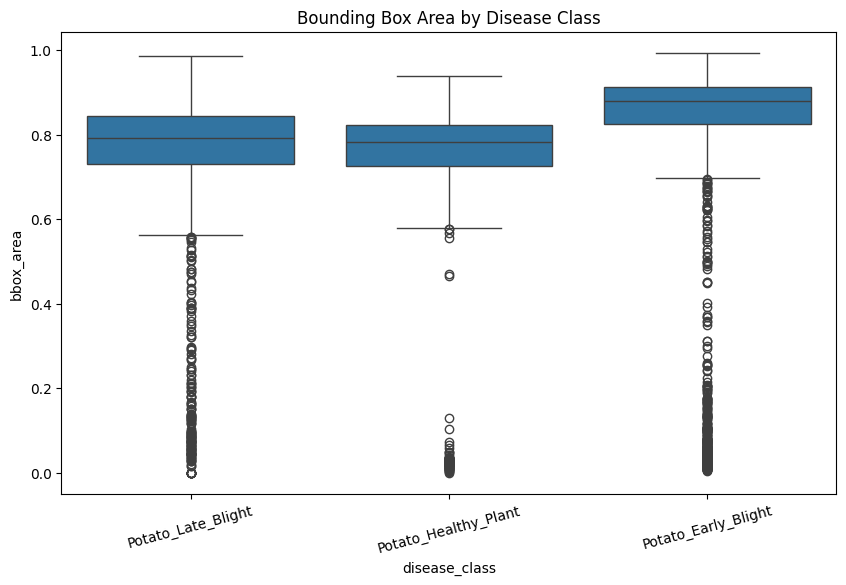

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='disease_class',
    y='bbox_area'
)

plt.title("Bounding Box Area by Disease Class")
plt.xticks(rotation=15)
plt.show()

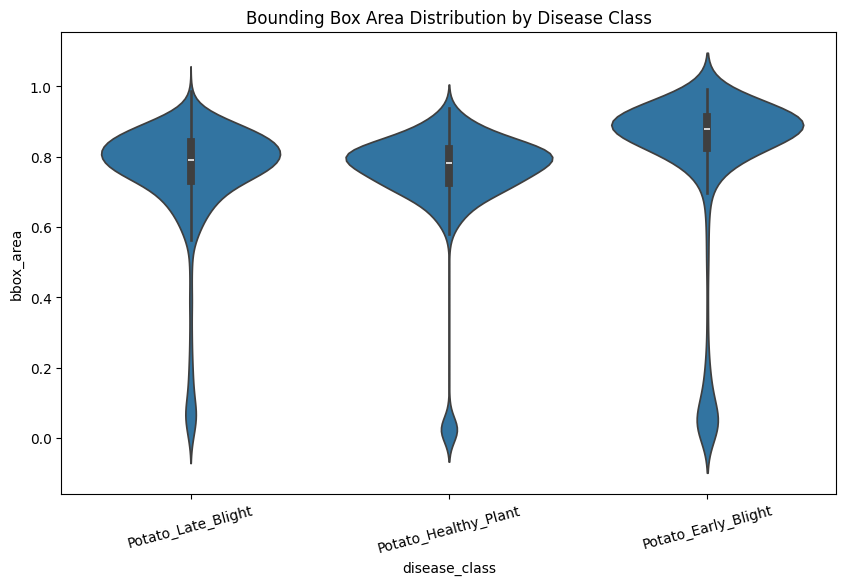

In [20]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='disease_class',
    y='bbox_area'
)

plt.title("Bounding Box Area Distribution by Disease Class")
plt.xticks(rotation=15)
plt.show()

In [21]:
corr_matrix = df[features].corr()

corr_matrix

,bbox_area,aspect_ratio,center_distance,bbox_perimeter,bbox_diagonal,area_to_perimeter_ratio
bbox_area,1.000000,0.143794,-0.872612,0.983797,0.980648,0.985471
aspect_ratio,0.143794,1.000000,-0.145755,0.137332,0.131057,0.149706
center_distance,-0.872612,-0.145755,1.000000,-0.907639,-0.902911,-0.913532
bbox_perimeter,0.983797,0.137332,-0.907639,1.000000,0.999274,0.996894
bbox_diagonal,0.980648,0.131057,-0.902911,0.999274,1.000000,0.993177
area_to_perimeter_ratio,0.985471,0.149706,-0.913532,0.996894,0.993177,1.000000


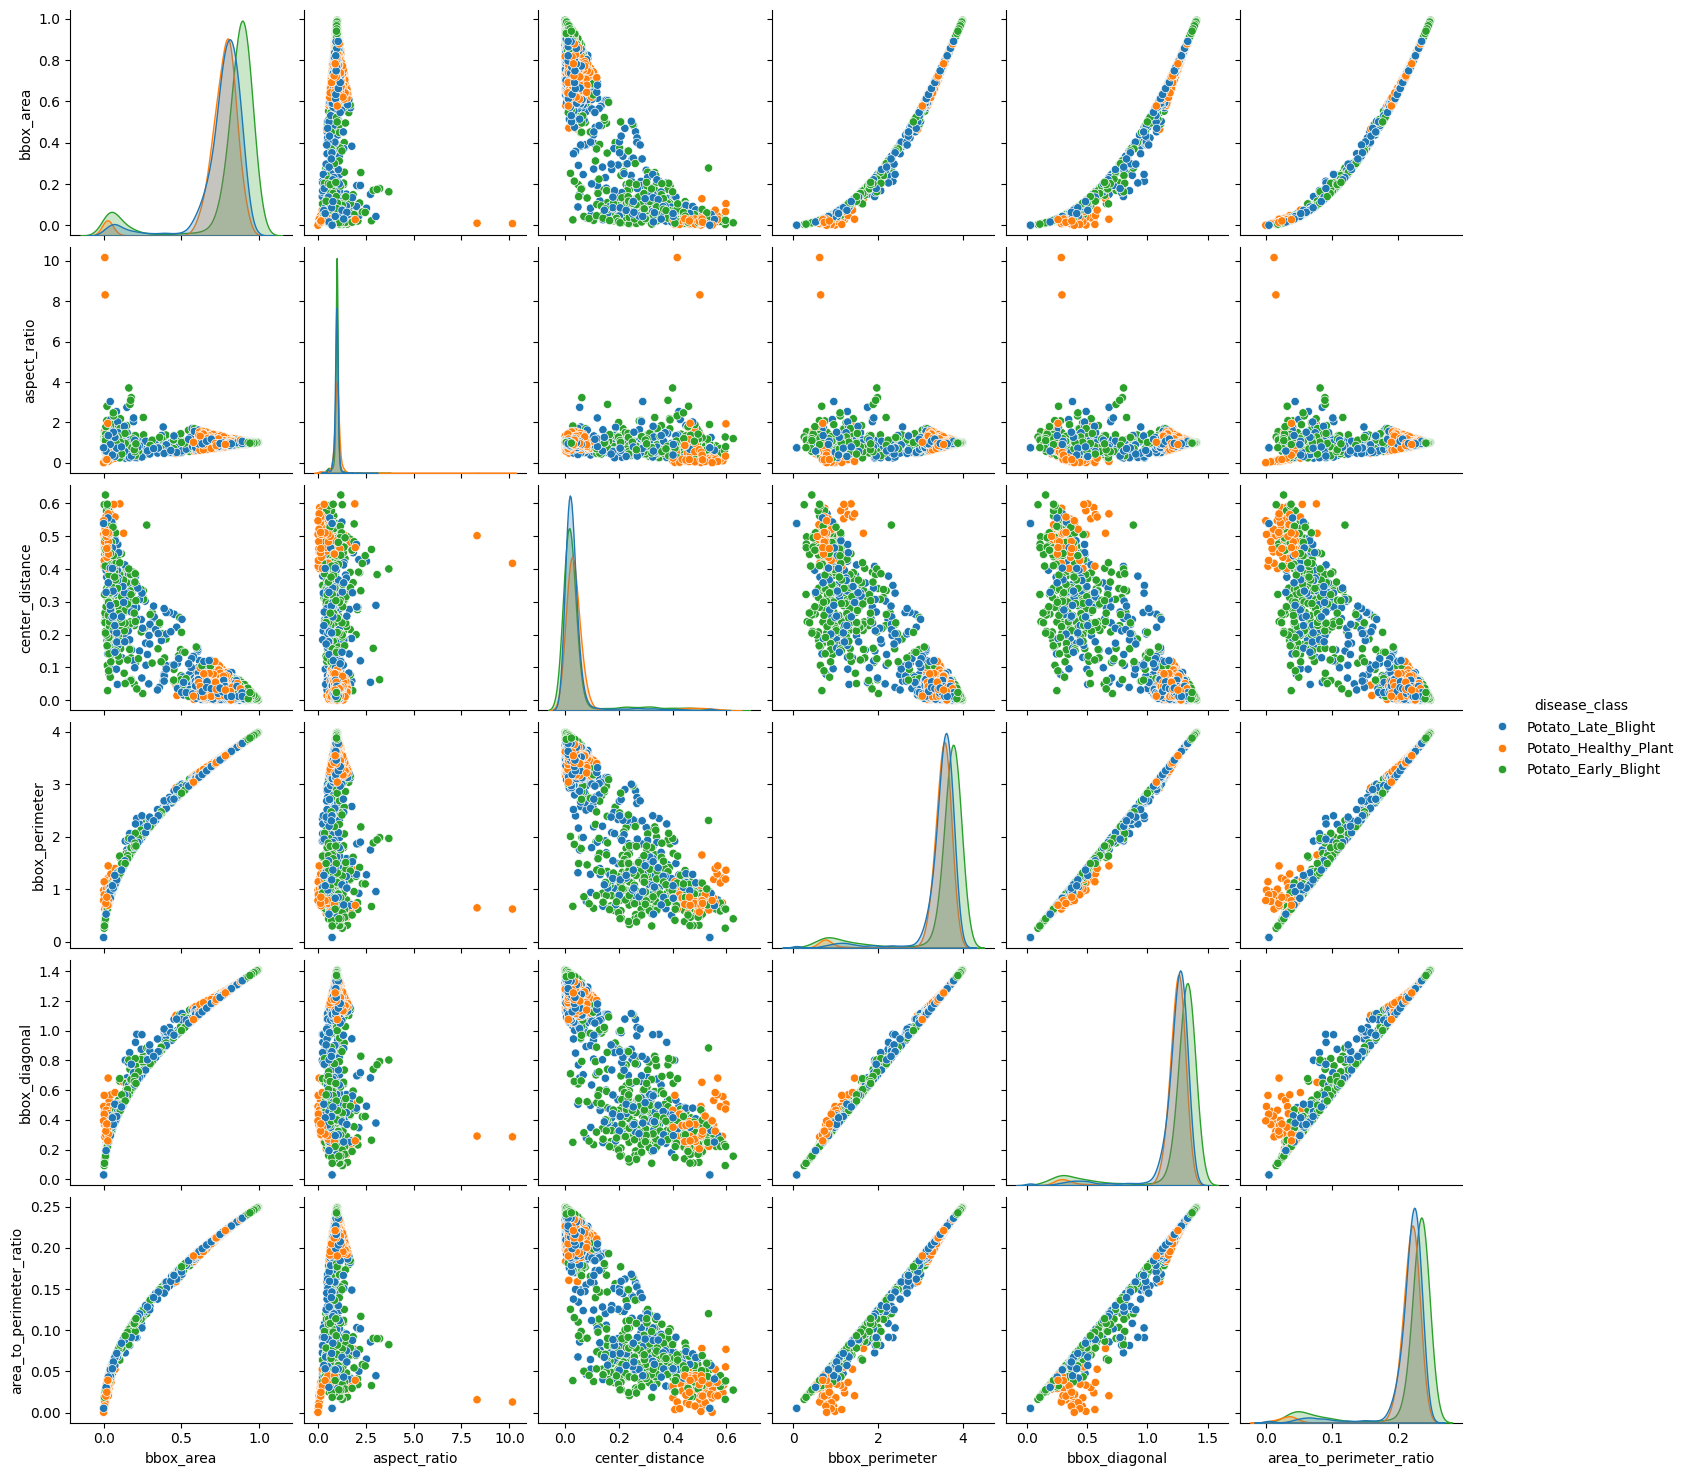

In [22]:
import seaborn as sns

sns.pairplot(
    df[
        [
            'bbox_area',
            'aspect_ratio',
            'center_distance',
            'bbox_perimeter',
            'bbox_diagonal',
            'area_to_perimeter_ratio',
            'disease_class'
        ]
    ],
    hue='disease_class'
)

plt.show()-

In [24]:
import matplotlib.pyplot as plt

plt.close('all')

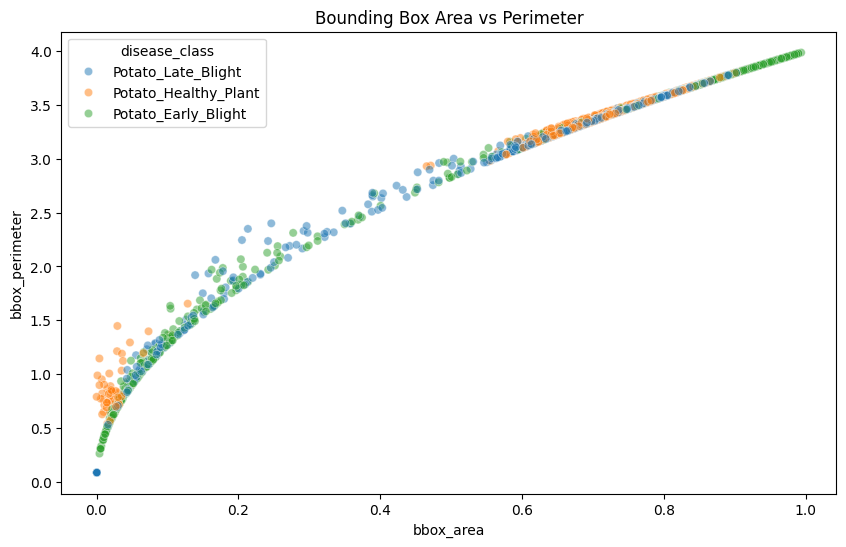

In [25]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='bbox_area',
    y='bbox_perimeter',
    hue='disease_class',
    alpha=0.5
)

plt.title("Bounding Box Area vs Perimeter")
plt.show()

### Observation

The distribution plots reveal noticeable differences in bounding box characteristics among disease classes.

Key findings include:

- Potato Early Blight exhibits slightly larger average bounding box areas.
- Healthy Plant samples demonstrate relatively stable geometric distributions.
- Most samples cluster within similar size ranges, indicating dataset consistency.
- Outliers are present but do not dominate the overall distributions.

The observed patterns support the statistical findings obtained through ANOVA testing.

# Conclusion

Week 2 focused on advanced statistical analysis and feature engineering of the potato disease dataset.

Key accomplishments include:

- Development of six engineered geometric features.
- Comprehensive descriptive statistical analysis.
- Disease-wise comparison of feature behavior.
- Correlation analysis among extracted features.
- Statistical significance testing using ANOVA.
- Visualization of feature distributions using box plots and violin plots.

The analysis demonstrates that several geometric features vary significantly among disease categories and may contribute valuable information for predictive modeling.

The dataset is now prepared for machine learning experimentation and model development in the subsequent stages of the project.

# Week 2 Status

✅ Feature Engineering Completed

✅ Statistical Summary Completed

✅ Disease-wise Feature Analysis Completed

✅ Correlation Analysis Completed

✅ Correlation Heatmap Completed

✅ ANOVA Statistical Testing Completed

✅ Advanced Visualizations Completed

✅ Week 2 Deliverables Achieved